<a href="https://colab.research.google.com/github/AliciaV15/product-sales-prediction-ml/blob/master/2ProductWiseSalesPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
print("🔧 GPU Setup Check:")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print(f"Built with CUDA: {tf.test.is_built_with_cuda()}")

🔧 GPU Setup Check:
TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Built with CUDA: True


In [ ]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU memory growth enabled")
    except RuntimeError as e:
        print(f"⚠️ GPU setup warning: {e}")

# Mixed precision for faster training on T4
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print("✅ Mixed precision enabled for faster training")

✅ GPU memory growth enabled
✅ Mixed precision enabled for faster training


In [ ]:
!pip install tensorflow scikit-learn matplotlib seaborn pandas numpy --quiet

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import os
import zipfile
import glob

warnings.filterwarnings('ignore')

# Data Procesing


In [ ]:
data_path = "/content/data/"

print(f"=== VERIFYING DATA DIRECTORY ===")
print(f"Data path: {data_path}")

if os.path.exists(data_path):
    print("✓ Data directory found")

    # List all files in the directory
    files = os.listdir(data_path)
    print(f"✓ Files found: {len(files)}")

    # Show ZIP files specifically
    zip_files = [f for f in files if f.endswith('.zip') and 'sales_detail' in f]
    csv_files = [f for f in files if f.endswith('.csv') and 'sales_detail' in f]

    print(f"   - Sales ZIP files: {len(zip_files)}")
    for zip_file in sorted(zip_files):
        print(f"     • {zip_file}")

    print(f"   - Sales CSV files: {len(csv_files)}")
    for csv_file in sorted(csv_files):
        print(f"     • {csv_file}")

    if len(zip_files) == 0 and len(csv_files) == 0:
        print("⚠️  No sales files found (sales_detail_*)")
        print("   Files available in the directory:")
        for file in sorted(files):
            print(f"     • {file}")

else:
    print("✗ Data directory NOT found")
    print("  Make sure to upload your files to /content/data/")
    print("  Or run: !mkdir -p /content/data")

=== VERIFYING DATA DIRECTORY ===
Data path: /content/data/
✓ Data directory found
✓ Files found: 27
   - Sales ZIP files: 27
     • sales_detail_2023_01.zip
     • sales_detail_2023_02.zip
     • sales_detail_2023_03.zip
     • sales_detail_2023_04.zip
     • sales_detail_2023_05.zip
     • sales_detail_2023_06.zip
     • sales_detail_2023_07.zip
     • sales_detail_2023_08.zip
     • sales_detail_2023_09.zip
     • sales_detail_2023_10.zip
     • sales_detail_2023_11.zip
     • sales_detail_2023_12.zip
     • sales_detail_2024_01.zip
     • sales_detail_2024_02.zip
     • sales_detail_2024_03.zip
     • sales_detail_2024_04.zip
     • sales_detail_2024_05.zip
     • sales_detail_2024_06.zip
     • sales_detail_2024_07.zip
     • sales_detail_2024_08.zip
     • sales_detail_2024_09.zip
     • sales_detail_2024_10.zip
     • sales_detail_2024_11.zip
     • sales_detail_2024_12.zip
     • sales_detail_2025_01.zip
     • sales_detail_2025_02.zip
     • sales_detail_2025_03.zip
   - Sales 

In [ ]:
def extract_and_load_data(data_path="/content/data/"):
    """
    Extracts ZIP files and loads all CSVs from the specified path.
    """
    all_data = []

    # Ensure the path ends with /
    if not data_path.endswith('/'):
        data_path += '/'

    print(f"Searching for files in: {data_path}")

    # Search for all ZIP files in the data folder
    zip_pattern = os.path.join(data_path, "sales_detail_*.zip")
    csv_pattern = os.path.join(data_path, "sales_detail_*.csv")

    zip_files = glob.glob(zip_pattern)

    if not zip_files:
        print("No ZIP files found. Searching for CSVs directly...")
        csv_files = glob.glob(csv_pattern)

        if not csv_files:
            print(f"No files found in {data_path}")
            print("Files available in the directory:")
            try:
                available_files = os.listdir(data_path)
                for file in available_files:
                    print(f"  - {file}")
            except:
                print("  Could not access the directory")
            return pd.DataFrame()  # Returns empty DataFrame

        for csv_file in csv_files:
            print(f"Loading {csv_file}...")
            df = pd.read_csv(csv_file)
            all_data.append(df)
    else:
        print(f"Found {len(zip_files)} ZIP files")
        for zip_file in zip_files:
            print(f"Extracting {os.path.basename(zip_file)}...")

            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                # List files in the ZIP
                file_list = zip_ref.namelist()
                csv_files_in_zip = [f for f in file_list if f.endswith('.csv')]

                for csv_file in csv_files_in_zip:
                    print(f"  Loading {csv_file} from {os.path.basename(zip_file)}...")
                    with zip_ref.open(csv_file) as file:
                        df = pd.read_csv(file)
                        all_data.append(df)

    if not all_data:
        raise ValueError("Could not load data. Make sure the files are present in /content/data/")

    # Combine all DataFrames
    combined_data = pd.concat(all_data, ignore_index=True)
    print(f"✓ Data loaded: {len(combined_data)} records from {len(all_data)} files")

    return combined_data

In [ ]:
print("=== LOADING DATA ===")
try:
    raw_data = extract_and_load_data()
    print(f"✓ Data successfully loaded: {len(raw_data)} records")
    print(f"✓ Available columns: {list(raw_data.columns)}")
    print(f"✓ Date range: {raw_data['Sales_Order_Date'].min()} to {raw_data['Sales_Order_Date'].max()}")

    # Show data sample
    print("\n--- DATA SAMPLE ---")
    print(raw_data.head())

    # Show data info
    print("\n--- DATA INFO ---")
    print(raw_data.info())

    # Show basic statistics
    print("\n--- BASIC STATISTICS ---")
    print(raw_data.describe())

except Exception as e:
    print(f"✗ Error loading data: {e}")
    print("Make sure the ZIP/CSV files are in the correct directory")

=== LOADING DATA ===
Searching for files in: /content/data/
Found 27 ZIP files
Extracting sales_detail_2024_05.zip...
  Loading sales_detail_2024_05.csv from sales_detail_2024_05.zip...
Extracting sales_detail_2025_01.zip...
  Loading sales_detail_2025_01.csv from sales_detail_2025_01.zip...
Extracting sales_detail_2023_01.zip...
  Loading sales_detail_2023_01.csv from sales_detail_2023_01.zip...
Extracting sales_detail_2023_05.zip...
  Loading sales_detail_2023_05.csv from sales_detail_2023_05.zip...
Extracting sales_detail_2024_08.zip...
  Loading sales_detail_2024_08.csv from sales_detail_2024_08.zip...
Extracting sales_detail_2023_09.zip...
  Loading sales_detail_2023_09.csv from sales_detail_2023_09.zip...
Extracting sales_detail_2025_02.zip...
  Loading sales_detail_2025_02.csv from sales_detail_2025_02.zip...
Extracting sales_detail_2024_06.zip...
  Loading sales_detail_2024_06.csv from sales_detail_2024_06.zip...
Extracting sales_detail_2024_11.zip...
  Loading sales_detail_202

# Model

In [ ]:
class ProductSalesPredictor:
    def __init__(self):
        self.model = None
        self.scaler_features = StandardScaler()
        self.scaler_target = StandardScaler()
        self.label_encoders = {}
        self.feature_columns = None
        self.product_stats = None

    def prepare_data(self, df):
        """
        Prepare data for product-wise sales prediction
        """
        print("=== PREPARING DATA FOR PRODUCT-WISE SALES PREDICTION ===")

        # Create a copy of the dataframe
        data = df.copy()

        # Convert date column to datetime
        data['Sales_Order_Date'] = pd.to_datetime(data['Sales_Order_Date'])

        # Extract additional time features
        data['Day'] = data['Sales_Order_Date'].dt.day
        data['Day_of_Week'] = data['Sales_Order_Date'].dt.dayofweek
        data['Quarter'] = data['Sales_Order_Date'].dt.quarter
        data['Is_Weekend'] = (data['Day_of_Week'] >= 5).astype(int)

        # Calculate product-level statistics (historical performance)
        product_stats = data.groupby('Product').agg({
            'Total_Price': ['mean', 'std', 'sum', 'count'],
            'Quantity': ['mean', 'std', 'sum'],
            'Unit_Price': ['mean', 'std'],
            'Discount': ['mean', 'std']
        }).round(4)

        # Flatten column names
        product_stats.columns = ['_'.join(col).strip() for col in product_stats.columns.values]
        product_stats = product_stats.reset_index()

        # Store product stats for later use
        self.product_stats = product_stats

        # Merge product statistics back to main data
        data = data.merge(product_stats, on='Product', how='left')

        # Fill any NaN values with 0 (for products with limited history)
        numeric_cols = data.select_dtypes(include=[np.number]).columns
        data[numeric_cols] = data[numeric_cols].fillna(0)

        print(f"✓ Data shape after preparation: {data.shape}")
        print(f"✓ Number of unique products: {data['Product'].nunique()}")

        return data

    def create_features(self, data):
        """
        Create feature matrix for the model
        """
        print("=== CREATING FEATURES ===")

        # Initialize label encoders for categorical variables
        categorical_columns = ['Product', 'Category', 'Region', 'Customer_Type']

        for col in categorical_columns:
            if col not in self.label_encoders:
                self.label_encoders[col] = LabelEncoder()
                data[f'{col}_encoded'] = self.label_encoders[col].fit_transform(data[col])
            else:
                # For prediction phase, handle unseen categories
                try:
                    data[f'{col}_encoded'] = self.label_encoders[col].transform(data[col])
                except ValueError:
                    # Handle unseen categories by assigning a default value
                    data[f'{col}_encoded'] = 0

        # Select features for the model
        feature_columns = [
            'Product_encoded', 'Category_encoded', 'Region_encoded', 'Customer_Type_encoded',
            'Unit_Price', 'Quantity', 'Discount', 'Year', 'Month', 'Day', 'Day_of_Week', 'Quarter', 'Is_Weekend',
            'Total_Price_mean', 'Total_Price_std', 'Total_Price_sum', 'Total_Price_count',
            'Quantity_mean', 'Quantity_std', 'Quantity_sum',
            'Unit_Price_mean', 'Unit_Price_std',
            'Discount_mean', 'Discount_std'
        ]

        # Store feature columns for later use
        self.feature_columns = feature_columns

        # Create feature matrix
        X = data[feature_columns].copy()

        # Fill any remaining NaN values
        X = X.fillna(0)

        print(f"✓ Feature matrix shape: {X.shape}")
        print(f"✓ Features used: {len(feature_columns)}")

        return X, data['Total_Price']

    def build_model(self, input_dim):
        """
        Build optimized neural network model for product sales prediction
        """
        print("=== BUILDING OPTIMIZED NEURAL NETWORK MODEL ===")

        # Smaller, faster model optimized for GPU
        model = keras.Sequential([
            # Input layer - reduced size
            layers.Dense(64, activation='relu', input_shape=(input_dim,)),
            layers.Dropout(0.2),

            # Hidden layers - simplified architecture
            layers.Dense(32, activation='relu'),
            layers.Dropout(0.2),

            layers.Dense(16, activation='relu'),
            layers.Dropout(0.1),

            # Output layer
            layers.Dense(1, activation='linear')
        ])

        # Compile model with optimized settings
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.01),  # Higher learning rate for faster convergence
            loss='mse',
            metrics=['mae']
        )

        print(f"✓ Optimized model built with {model.count_params()} parameters")
        print(f"✓ Model is {model.count_params()} parameters (much smaller for faster training)")
        return model

    def calculate_metrics(self, y_true, y_pred):
        """
        Calculate evaluation metrics
        """
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)

        # Calculate MAPE (Mean Absolute Percentage Error)
        mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

        return {
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'R2_Score': r2,
            'MAPE': mape
        }

print("✅ ProductSalesPredictor class defined successfully!")

✅ ProductSalesPredictor class defined successfully!


In [ ]:
def train_model(self, X, y, validation_split=0.2, epochs=30, batch_size=256):
    """
    Train the neural network model - OPTIMIZED FOR SPEED
    """
    print("=== TRAINING OPTIMIZED MODEL ===")

    # Use subset for very large datasets to speed up training
    if len(X) > 50000:
        print(f"⚡ Large dataset detected ({len(X)} samples). Using sample for faster training...")
        sample_size = 50000
        sample_indices = np.random.choice(len(X), sample_size, replace=False)
        X_sample = X.iloc[sample_indices]
        y_sample = y.iloc[sample_indices]
        print(f"✓ Using sample of {sample_size} records for training")
    else:
        X_sample = X
        y_sample = y

    # Split data for training and validation
    X_train, X_val, y_train, y_val = train_test_split(
        X_sample, y_sample, test_size=validation_split, random_state=42, stratify=None
    )

    # Scale features
    X_train_scaled = self.scaler_features.fit_transform(X_train)
    X_val_scaled = self.scaler_features.transform(X_val)

    # Scale target variable
    y_train_scaled = self.scaler_target.fit_transform(y_train.values.reshape(-1, 1)).flatten()
    y_val_scaled = self.scaler_target.transform(y_val.values.reshape(-1, 1)).flatten()

    # Build model
    self.model = self.build_model(X_train_scaled.shape[1])

    # Define callbacks - more aggressive for faster training
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,  # Reduced patience
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,  # Reduced patience
            min_lr=0.001
        )
    ]

    print(f"🚀 Training with optimized settings:")
    print(f"   - Training samples: {len(X_train)}")
    print(f"   - Validation samples: {len(X_val)}")
    print(f"   - Batch size: {batch_size}")
    print(f"   - Max epochs: {epochs}")
    print(f"   - Early stopping patience: 5")

    # Train model with larger batch size for GPU efficiency
    history = self.model.fit(
        X_train_scaled, y_train_scaled,
        validation_data=(X_val_scaled, y_val_scaled),
        epochs=epochs,
        batch_size=batch_size,  # Larger batch size for GPU
        callbacks=callbacks,
        verbose=1
    )

    # Make predictions for evaluation
    y_train_pred_scaled = self.model.predict(X_train_scaled, batch_size=batch_size)
    y_val_pred_scaled = self.model.predict(X_val_scaled, batch_size=batch_size)

    # Inverse transform predictions
    y_train_pred = self.scaler_target.inverse_transform(y_train_pred_scaled).flatten()
    y_val_pred = self.scaler_target.inverse_transform(y_val_pred_scaled).flatten()

    # Calculate metrics
    train_metrics = self.calculate_metrics(y_train, y_train_pred)
    val_metrics = self.calculate_metrics(y_val, y_val_pred)

    print(f"\n=== TRAINING RESULTS (Completed in {len(history.history['loss'])} epochs) ===")
    print(f"Training Metrics:")
    for metric, value in train_metrics.items():
        print(f"  {metric}: {value:.4f}")

    print(f"\nValidation Metrics:")
    for metric, value in val_metrics.items():
        print(f"  {metric}: {value:.4f}")

    return history, (X_train, X_val, y_train, y_val, y_train_pred, y_val_pred)

def predict(self, X):
    """
    Make predictions using the trained model
    """
    if self.model is None:
        raise ValueError("Model not trained yet. Call train_model first.")

    # Scale features
    X_scaled = self.scaler_features.transform(X)

    # Make predictions
    y_pred_scaled = self.model.predict(X_scaled)

    # Inverse transform predictions
    y_pred = self.scaler_target.inverse_transform(y_pred_scaled).flatten()

    return y_pred

# Add methods to the class
ProductSalesPredictor.train_model = train_model
ProductSalesPredictor.predict = predict

print("✅ Training and prediction methods added to ProductSalesPredictor!")

✅ Training and prediction methods added to ProductSalesPredictor!


# Training

In [ ]:
def plot_training_history(self, history):
    """
    Plot training history
    """
    plt.figure(figsize=(12, 4))

    # Plot training & validation loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot training & validation MAE
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Training MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.title('Model MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()

    plt.tight_layout()

In [ ]:
def plot_predictions_vs_actual(self, y_true, y_pred, title="Predictions vs Actual"):
    """
    Plot predictions vs actual values
    """
    plt.figure(figsize=(10, 6))

    plt.subplot(1, 2, 1)
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.xlabel('Actual Sales')
    plt.ylabel('Predicted Sales')
    plt.title(f'{title} - Scatter Plot')

    plt.subplot(1, 2, 2)
    residuals = y_true - y_pred
    plt.hist(residuals, bins=50, alpha=0.7)
    plt.xlabel('Residuals (Actual - Predicted)')
    plt.ylabel('Frequency')
    plt.title('Residuals Distribution')

    plt.tight_layout()
    plt.show()

In [ ]:
def analyze_product_performance(self, df):
    """
    Analyze performance by product
    """
    print("=== PRODUCT PERFORMANCE ANALYSIS ===")

    product_analysis = df.groupby('Product').agg({
        'Total_Price': ['sum', 'mean', 'count', 'std']
    }).round(2)

    product_analysis.columns = ['Total_Sales', 'Avg_Sale', 'Order_Count', 'Sales_Std']
    product_analysis = product_analysis.reset_index().sort_values('Total_Sales', ascending=False)

    print("\nTop 10 Products by Total Sales:")
    print(product_analysis.head(10))

    # Plot top products
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    top_10 = product_analysis.head(10)
    plt.bar(range(len(top_10)), top_10['Total_Sales'])
    plt.xticks(range(len(top_10)), top_10['Product'], rotation=45, ha='right')
    plt.title('Top 10 Products by Total Sales')
    plt.ylabel('Total Sales ($)')

    plt.subplot(1, 2, 2)
    plt.bar(range(len(top_10)), top_10['Avg_Sale'])
    plt.xticks(range(len(top_10)), top_10['Product'], rotation=45, ha='right')
    plt.title('Top 10 Products by Average Sale')
    plt.ylabel('Average Sale ($)')

    plt.tight_layout()
    plt.show()

    return product_analysis

In [ ]:
def predict_product_sales(self, df_2025, product_name):
    """
    Predict sales for a specific product in 2025
    """
    print(f"=== PREDICTING SALES FOR PRODUCT: {product_name} ===")

    # Filter data for the specific product
    product_data = df_2025[df_2025['Product'] == product_name].copy()

    if len(product_data) == 0:
        print(f"⚠️  No data found for product: {product_name}")
        return None

    # Prepare features for prediction
    X_pred, _ = self.create_features(product_data)

    # Make predictions
    predictions = self.predict(X_pred)

    # Add predictions to the dataframe
    result_df = product_data.copy()
    result_df['Predicted_Sales'] = predictions
    result_df['Prediction_Date'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

    print(f"✓ Predictions generated for {len(predictions)} records")
    print(f"✓ Predicted total sales for {product_name}: ${predictions.sum():.2f}")
    print(f"✓ Average predicted sales per order: ${predictions.mean():.2f}")

    return result_df

# Add visualization methods to the class
ProductSalesPredictor.plot_training_history = plot_training_history
ProductSalesPredictor.plot_predictions_vs_actual = plot_predictions_vs_actual
ProductSalesPredictor.analyze_product_performance = analyze_product_performance
ProductSalesPredictor.predict_product_sales = predict_product_sales

print("✅ Visualization and analysis methods added to ProductSalesPredictor!")

✅ Visualization and analysis methods added to ProductSalesPredictor!


In [ ]:
print("🚀 STARTING PRODUCT-WISE SALES PREDICTION PIPELINE")

# Initialize predictor
predictor = ProductSalesPredictor()

# Split data by year
training_data = raw_data[raw_data['Year'].isin([2023, 2024])].copy()
test_data = raw_data[raw_data['Year'] == 2025].copy()

print(f"✓ Training data: {len(training_data)} records")
print(f"✓ Test data: {len(test_data)} records")

# Basic data exploration
print("\n=== DATA EXPLORATION ===")
print(f"Training data date range: {training_data['Sales_Order_Date'].min()} to {training_data['Sales_Order_Date'].max()}")
print(f"Test data date range: {test_data['Sales_Order_Date'].min()} to {test_data['Sales_Order_Date'].max()}")
print(f"Unique products in training: {training_data['Product'].nunique()}")
print(f"Unique products in test: {test_data['Product'].nunique()}")

🚀 STARTING PRODUCT-WISE SALES PREDICTION PIPELINE
✓ Training data: 6005253 records
✓ Test data: 740078 records

=== DATA EXPLORATION ===
Training data date range: 2023-01-01 to 2024-12-31
Test data date range: 2025-01-01 to 2025-03-31
Unique products in training: 47
Unique products in test: 47


In [ ]:
print("=== PREPARING TRAINING DATA ===")
prepared_data = predictor.prepare_data(training_data)

# Display product statistics
print("\n=== TOP PRODUCTS BY HISTORICAL PERFORMANCE ===")
print(predictor.product_stats.head(10))

# Create features and target
X, y = predictor.create_features(prepared_data)

print(f"\n=== FEATURE SUMMARY ===")
print(f"Feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print(f"Feature columns: {predictor.feature_columns}")

=== PREPARING TRAINING DATA ===
=== PREPARING DATA FOR PRODUCT-WISE SALES PREDICTION ===
✓ Data shape after preparation: (6005253, 28)
✓ Number of unique products: 47

=== TOP PRODUCTS BY HISTORICAL PERFORMANCE ===
             Product  Total_Price_mean  Total_Price_std  Total_Price_sum  \
0        Apollinaris           20.3644          26.8375       3380294.83   
1         Augustiner           40.7023          60.0998       3135336.05   
2            Bacardi          503.7172         765.7101      38707142.98   
3             Beck's           32.5613          41.4291       3071702.01   
4         Chardonnay          179.0793         278.9359      13762064.84   
5          Club Mate           46.6359          55.1630       5578023.98   
6          Coca-Cola           23.4683          29.5711       3102534.59   
7    Cranberry Juice           71.1903          83.1548      15166376.64   
8  Erdinger Weißbier           45.6115          58.9774       3565682.75   
9              Evian     

In [ ]:
print("=== STARTING MODEL TRAINING ===")

# Train the model with optimized settings
history, train_results = predictor.train_model(X, y, epochs=30, batch_size=256)

# Extract training results
X_train, X_val, y_train, y_val, y_train_pred, y_val_pred = train_results

print("✅ Model training completed!")

=== STARTING MODEL TRAINING ===
=== TRAINING OPTIMIZED MODEL ===
⚡ Large dataset detected (6005253 samples). Using sample for faster training...
✓ Using sample of 50000 records for training
=== BUILDING OPTIMIZED NEURAL NETWORK MODEL ===
✓ Optimized model built with 4225 parameters
✓ Model is 4225 parameters (much smaller for faster training)
🚀 Training with optimized settings:
   - Training samples: 40000
   - Validation samples: 10000
   - Batch size: 256
   - Max epochs: 30
   - Early stopping patience: 5
Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 0.3294 - mae: 0.2033 - val_loss: 0.2633 - val_mae: 0.1416 - learning_rate: 0.0100
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.1793 - mae: 0.1323 - val_loss: 0.0372 - val_mae: 0.0806 - learning_rate: 0.0100
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1025 - mae: 0.1107 - val_loss: 0.0780 - val_mae: 0.1055 - learning_rate: 0.0100
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss

# Results

=== VISUALIZING TRAINING RESULTS ===


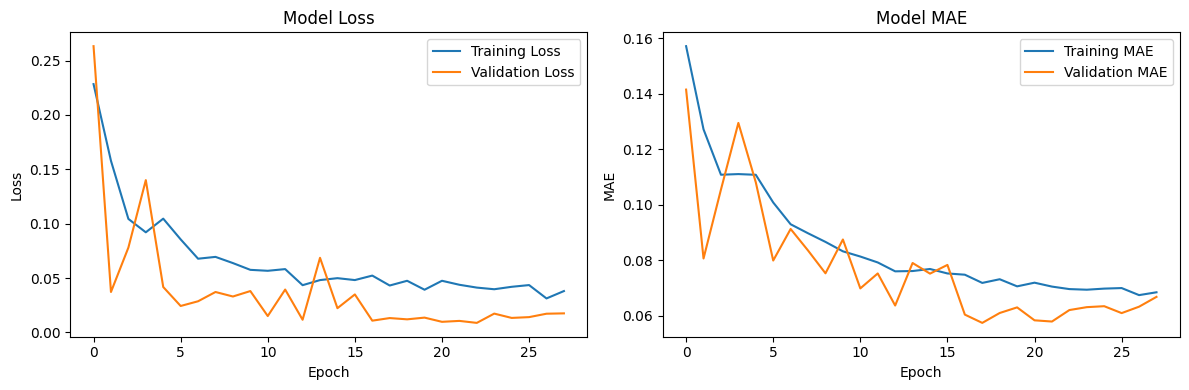

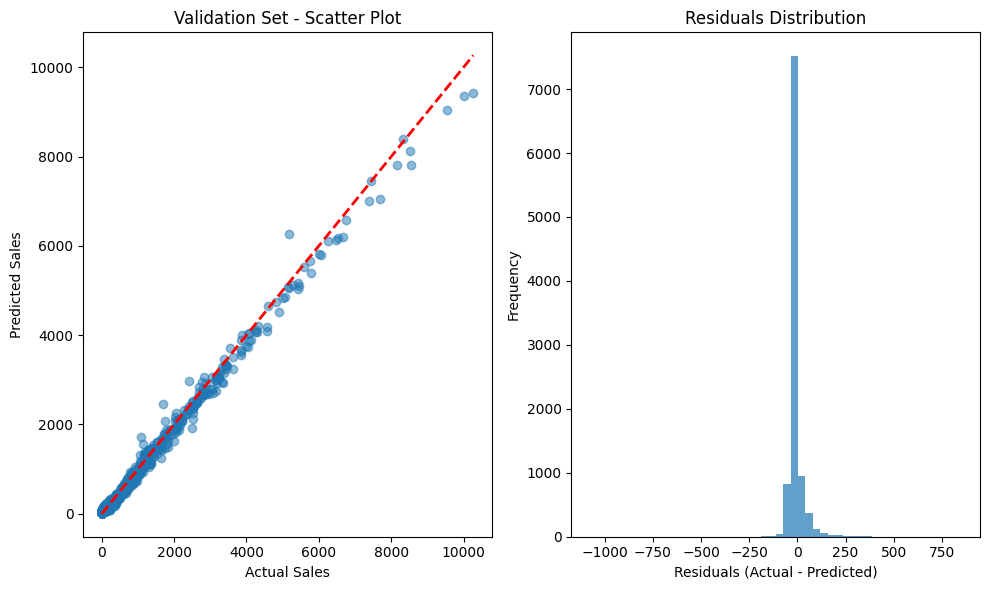

In [ ]:
print("=== VISUALIZING TRAINING RESULTS ===")

# Plot training history
predictor.plot_training_history(history)

# Plot predictions vs actual for validation set
predictor.plot_predictions_vs_actual(y_val, y_val_pred, "Validation Set")

=== ANALYZING PRODUCT PERFORMANCE ===
=== PRODUCT PERFORMANCE ANALYSIS ===

Top 10 Products by Total Sales:
            Product   Total_Sales  Avg_Sale  Order_Count  Sales_Std
41   Veuve Clicquot  1.337776e+08   1736.15        77054    1991.88
26   Moët & Chandon  1.155763e+08   1508.81        76601    2134.23
18   Johnnie Walker  6.399990e+07    830.06        77103    1088.17
16     Jack Daniels  6.309858e+07    819.08        77036     912.11
39        Tanqueray  5.660246e+07    737.47        76752     939.28
2           Bacardi  3.870714e+07    503.72        76843     765.71
14      Havana Club  3.806142e+07    496.76        76620     766.17
35  Sauvignon Blanc  1.543765e+07    200.26        77088     271.82
7   Cranberry Juice  1.516638e+07     71.19       213040      83.15
31         Riesling  1.492915e+07    179.11        83351     285.99


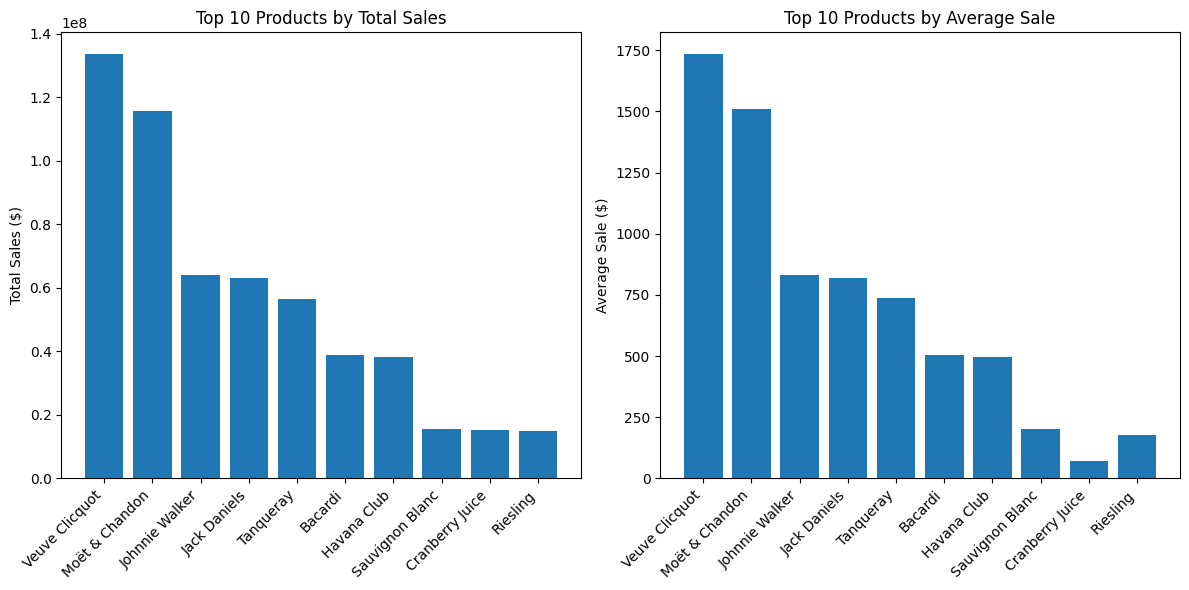


=== DETAILED PRODUCT STATISTICS ===
Total number of products: 47
Top product total sales: $133777583.20
Average sales per product: $16487370.79
Median sales per product: $5578023.98


In [ ]:
print("=== ANALYZING PRODUCT PERFORMANCE ===")

# Analyze product performance
product_analysis = predictor.analyze_product_performance(training_data)

# Show additional statistics
print("\n=== DETAILED PRODUCT STATISTICS ===")
print(f"Total number of products: {len(product_analysis)}")
print(f"Top product total sales: ${product_analysis.iloc[0]['Total_Sales']:.2f}")
print(f"Average sales per product: ${product_analysis['Total_Sales'].mean():.2f}")
print(f"Median sales per product: ${product_analysis['Total_Sales'].median():.2f}")

=== TESTING ON 2025 DATA ===
=== PREPARING DATA FOR PRODUCT-WISE SALES PREDICTION ===
✓ Data shape after preparation: (740078, 28)
✓ Number of unique products: 47
=== CREATING FEATURES ===
✓ Feature matrix shape: (740078, 24)
✓ Features used: 24
23128/23128 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step
Test Set Metrics:
  MSE: 38602.8380
  RMSE: 196.4760
  MAE: 65.1610
  R2_Score: 0.8570
  MAPE: 307.7242


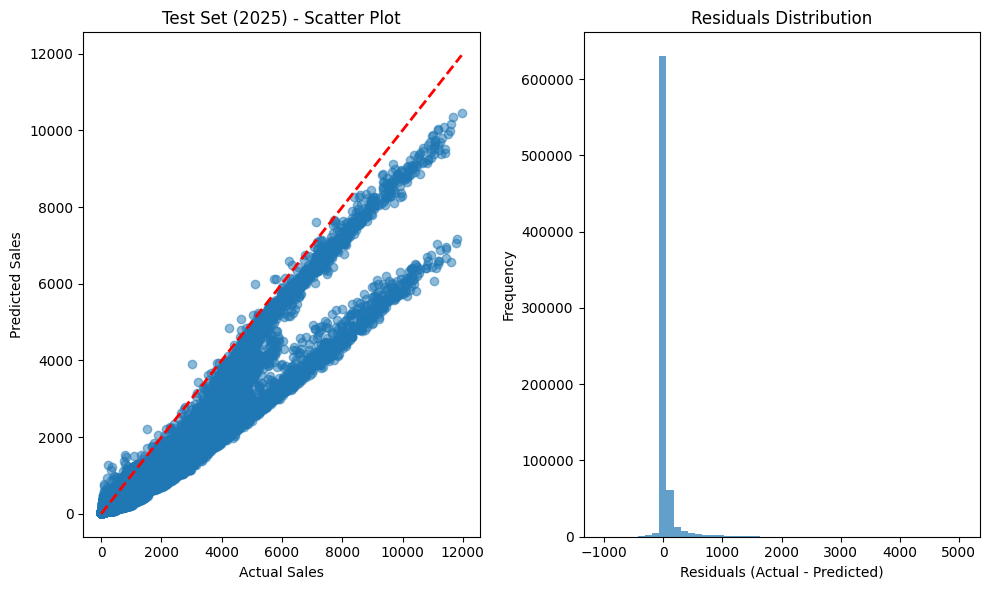

In [ ]:
if len(test_data) > 0:
    print("=== TESTING ON 2025 DATA ===")

    # Prepare test data
    test_prepared = predictor.prepare_data(test_data)
    X_test, y_test = predictor.create_features(test_prepared)

    # Make predictions
    y_test_pred = predictor.predict(X_test)

    # Calculate test metrics
    test_metrics = predictor.calculate_metrics(y_test, y_test_pred)

    print("Test Set Metrics:")
    for metric, value in test_metrics.items():
        print(f"  {metric}: {value:.4f}")

    # Plot test predictions
    predictor.plot_predictions_vs_actual(y_test, y_test_pred, "Test Set (2025)")

else:
    print("⚠️  No 2025 data available for testing")

In [ ]:
if len(test_data) > 0:
    print("=== PRODUCT-SPECIFIC PREDICTIONS FOR 2025 ===")

    # Get top 3 products from historical analysis
    top_products = product_analysis.head(3)['Product'].values
    print(f"Making predictions for top 3 products: {list(top_products)}")

    # Create predictions for each top product
    product_predictions_results = {}

    for product in top_products:
        print(f"\n--- Predicting for {product} ---")
        product_predictions = predictor.predict_product_sales(test_prepared, product)

        if product_predictions is not None:
            product_predictions_results[product] = product_predictions

            # Show sample predictions
            print(f"\n{product} - Sample predictions:")
            display_cols = ['Product', 'Region', 'Month', 'Quantity', 'Unit_Price', 'Predicted_Sales']
            print(product_predictions[display_cols].head())

            # Show monthly summary
            monthly_summary = product_predictions.groupby('Month').agg({
                'Predicted_Sales': ['sum', 'count', 'mean']
            }).round(2)
            monthly_summary.columns = ['Total_Predicted', 'Order_Count', 'Avg_Predicted']
            print(f"\nMonthly summary for {product}:")
            print(monthly_summary)


=== PRODUCT-SPECIFIC PREDICTIONS FOR 2025 ===
Making predictions for top 3 products: ['Veuve Clicquot', 'Moët & Chandon', 'Johnnie Walker']

--- Predicting for Veuve Clicquot ---
=== PREDICTING SALES FOR PRODUCT: Veuve Clicquot ===
=== CREATING FEATURES ===
✓ Feature matrix shape: (9450, 24)
✓ Features used: 24
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
✓ Predictions generated for 9450 records
✓ Predicted total sales for Veuve Clicquot: $inf
✓ Average predicted sales per order: $1692.00

Veuve Clicquot - Sample predictions:
            Product                  Region  Month  Quantity  Unit_Price  \
75   Veuve Clicquot                 Sachsen      1        14      112.46   
99   Veuve Clicquot      Schleswig-Holstein      1        10      112.46   
191  Veuve Clicquot     Nordrhein-Westfalen      1        14      112.46   
267  Veuve Clicquot  Mecklenburg-Vorpommern      1        38       36.74   
273  Veuve Clicquot      Schleswig-Holstein      1        12      112.46   

     Predicted_

In [ ]:
print("=== FINAL MODEL SUMMARY ===")

# Model architecture summary
print("\n--- Model Architecture ---")
if predictor.model is not None:
    predictor.model.summary()

# Performance summary
print("\n--- Performance Summary ---")
if len(test_data) > 0:
    print("Test Set Performance:")
    for metric, value in test_metrics.items():
        print(f"  {metric}: {value:.4f}")
else:
    print("Validation Set Performance:")
    val_metrics = predictor.calculate_metrics(y_val, y_val_pred)
    for metric, value in val_metrics.items():
        print(f"  {metric}: {value:.4f}")

# Feature importance (approximated by checking feature correlations)
print("\n--- Feature Analysis ---")
feature_df = pd.DataFrame({
    'Feature': predictor.feature_columns,
    'Index': range(len(predictor.feature_columns))
})
print(feature_df)

=== FINAL MODEL SUMMARY ===

--- Model Architecture ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,681 (49.55 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,456 (33.04 KB)


--- Performance Summary ---
Test Set Performance:
  MSE: 38602.8380
  RMSE: 196.4760
  MAE: 65.1610
  R2_Score: 0.8570
  MAPE: 307.7242

--- Feature Analysis ---
                  Feature  Index
0         Product_encoded      0
1        Category_encoded      1
2          Region_encoded      2
3   Customer_Type_encoded      3
4              Unit_Price      4
5                Quantity      5
6                Discount      6
7                    Year      7
8                   Month      8
9                     Day      9
10            Day_of_Week     10
11                Quarter     11
12             Is_Weekend     12
13       Total_Price_mean     13
14        Total_Price_std     14
15        Total_Price_sum     15
16      Total_Price_count     16
17          Quantity_mean     17
18           Quantity_std     18
19           Quantity_sum     19
20        Unit_Price_mean     20
21         Unit_Price_std     21
22          Discount_mean     22
23           Discount_std     23


# Results

In [ ]:
# =====================================
# PRODUCT-WISE MONTHLY SALES COMPARISON FOR 2025
# =====================================

def compare_product_sales_by_month(predictor, test_data):
    """
    Compare predicted vs actual sales by product for each month of 2025
    """
    print("🔍 PRODUCT-WISE SALES COMPARISON FOR 2025")
    print("="*80)

    if len(test_data) == 0:
        print("⚠️  No 2025 data available for comparison")
        return None

    # Prepare test data and make predictions
    test_prepared = predictor.prepare_data(test_data)
    X_test, y_test = predictor.create_features(test_prepared)
    y_test_pred = predictor.predict(X_test)

    # Add predictions to the prepared data
    test_prepared['Predicted_Sales'] = y_test_pred
    test_prepared['Actual_Sales'] = y_test

    # Get unique months in the data
    available_months = sorted(test_prepared['Month'].unique())
    print(f"📅 Available months in 2025 data: {available_months}")

    # Create comparison tables for each month
    monthly_results = {}
    monthly_accuracy = {}

    for month in available_months:
        print(f"\n{'='*50}")
        print(f"📊 MONTH {month} - 2025")
        print(f"{'='*50}")

        # Filter data for the current month
        month_data = test_prepared[test_prepared['Month'] == month].copy()

        # Group by product and sum sales
        product_comparison = month_data.groupby('Product').agg({
            'Actual_Sales': 'sum',
            'Predicted_Sales': 'sum',
            'Order_ID': 'count'  # Number of orders
        }).reset_index()

        product_comparison.columns = ['Product', 'Actual_Sales', 'Predicted_Sales', 'Orders']

        # Calculate accuracy metrics
        product_comparison['Absolute_Error'] = abs(product_comparison['Actual_Sales'] - product_comparison['Predicted_Sales'])
        product_comparison['Percentage_Error'] = (product_comparison['Absolute_Error'] / (product_comparison['Actual_Sales'] + 1e-8)) * 100
        product_comparison['Accuracy'] = 100 - product_comparison['Percentage_Error']

        # Ensure accuracy doesn't go negative and cap at 100%
        product_comparison['Accuracy'] = product_comparison['Accuracy'].clip(0, 100)

        # Sort by actual sales (descending)
        product_comparison = product_comparison.sort_values('Actual_Sales', ascending=False)

        # Format for display
        product_comparison['Actual_Sales'] = product_comparison['Actual_Sales'].round(2)
        product_comparison['Predicted_Sales'] = product_comparison['Predicted_Sales'].round(2)
        product_comparison['Absolute_Error'] = product_comparison['Absolute_Error'].round(2)
        product_comparison['Percentage_Error'] = product_comparison['Percentage_Error'].round(1)
        product_comparison['Accuracy'] = product_comparison['Accuracy'].round(1)

        # Display the comparison table
        print(f"\n📋 Product Sales Comparison - Month {month}:")
        print("-" * 120)
        print(f"{'Product':<25} {'Actual($)':<12} {'Predicted($)':<14} {'Error($)':<10} {'Error(%)':<10} {'Accuracy(%)':<12} {'Orders':<8}")
        print("-" * 120)

        for _, row in product_comparison.iterrows():
            product_name = row['Product'][:24]  # Truncate long names
            print(f"{product_name:<25} {row['Actual_Sales']:<12.2f} {row['Predicted_Sales']:<14.2f} "
                  f"{row['Absolute_Error']:<10.2f} {row['Percentage_Error']:<10.1f}% {row['Accuracy']:<12.1f}% {row['Orders']:<8.0f}")

        # Monthly summary statistics
        total_actual = product_comparison['Actual_Sales'].sum()
        total_predicted = product_comparison['Predicted_Sales'].sum()
        total_error = abs(total_actual - total_predicted)
        monthly_error_pct = (total_error / total_actual) * 100
        month_accuracy_pct = 100 - monthly_error_pct

        print("-" * 120)
        print(f"{'MONTH TOTALS:':<25} {total_actual:<12.2f} {total_predicted:<14.2f} "
              f"{total_error:<10.2f} {monthly_error_pct:<10.1f}% {month_accuracy_pct:<12.1f}% {product_comparison['Orders'].sum():<8.0f}")
        print("-" * 120)

        # Store results
        monthly_results[month] = product_comparison
        monthly_accuracy[month] = {
            'total_actual': total_actual,
            'total_predicted': total_predicted,
            'total_error': total_error,
            'error_percentage': monthly_error_pct,
            'accuracy': month_accuracy_pct,
            'num_products': len(product_comparison),
            'num_orders': product_comparison['Orders'].sum()
        }

        # Show top performers and worst performers
        print(f"\n🏆 TOP 5 MOST ACCURATE PRODUCTS (Month {month}):")
        top_accurate = product_comparison.nlargest(5, 'Accuracy')[['Product', 'Actual_Sales', 'Predicted_Sales', 'Accuracy']]
        for _, row in top_accurate.iterrows():
            print(f"   {row['Product'][:30]:<30}: {row['Accuracy']:.1f}% accuracy (${row['Actual_Sales']:.2f} vs ${row['Predicted_Sales']:.2f})")

        print(f"\n⚠️  5 PRODUCTS WITH HIGHEST ERRORS (Month {month}):")
        worst_accurate = product_comparison.nsmallest(5, 'Accuracy')[['Product', 'Actual_Sales', 'Predicted_Sales', 'Accuracy']]
        for _, row in worst_accurate.iterrows():
            print(f"   {row['Product'][:30]:<30}: {row['Accuracy']:.1f}% accuracy (${row['Actual_Sales']:.2f} vs ${row['Predicted_Sales']:.2f})")

    # Overall summary across all months
    print(f"\n{'='*80}")
    print(f"📈 OVERALL SUMMARY - FIRST {len(available_months)} MONTHS OF 2025")
    print(f"{'='*80}")

    # Calculate overall statistics
    overall_actual = sum([monthly_accuracy[month]['total_actual'] for month in available_months])
    overall_predicted = sum([monthly_accuracy[month]['total_predicted'] for month in available_months])
    overall_error = abs(overall_actual - overall_predicted)
    overall_error_pct = (overall_error / overall_actual) * 100
    overall_accuracy = 100 - overall_error_pct

    total_products = sum([monthly_accuracy[month]['num_products'] for month in available_months])
    total_orders = sum([monthly_accuracy[month]['num_orders'] for month in available_months])

    print(f"\n📊 MONTHLY ACCURACY BREAKDOWN:")
    print("-" * 100)
    print(f"{'Month':<8} {'Actual Sales($)':<15} {'Predicted Sales($)':<18} {'Error($)':<12} {'Error(%)':<10} {'Accuracy(%)':<12}")
    print("-" * 100)

    for month in available_months:
        data = monthly_accuracy[month]
        print(f"{month:<8} {data['total_actual']:<15.2f} {data['total_predicted']:<18.2f} "
              f"{data['total_error']:<12.2f} {data['error_percentage']:<10.1f}% {data['accuracy']:<12.1f}%")

    print("-" * 100)
    print(f"{'TOTAL:':<8} {overall_actual:<15.2f} {overall_predicted:<18.2f} "
          f"{overall_error:<12.2f} {overall_error_pct:<10.1f}% {overall_accuracy:<12.1f}%")
    print("-" * 100)

    # Average monthly accuracy
    avg_monthly_accuracy = sum([monthly_accuracy[month]['accuracy'] for month in available_months]) / len(available_months)

    print(f"\n🎯 FINAL RESULTS:")
    print(f"   📅 Months analyzed: {available_months}")
    print(f"   🛒 Total orders analyzed: {int(total_orders)}")
    print(f"   📦 Unique products: {len(set.union(*[set(monthly_results[month]['Product']) for month in available_months]))}")
    print(f"   💰 Total actual sales: ${overall_actual:,.2f}")
    print(f"   🔮 Total predicted sales: ${overall_predicted:,.2f}")
    print(f"   ❌ Total absolute error: ${overall_error:,.2f}")
    print(f"   📊 Overall accuracy: {overall_accuracy:.1f}%")
    print(f"   📈 Average monthly accuracy: {avg_monthly_accuracy:.1f}%")

    # Performance rating
    if overall_accuracy >= 90:
        rating = "🏆 EXCELLENT"
    elif overall_accuracy >= 80:
        rating = "✅ VERY GOOD"
    elif overall_accuracy >= 70:
        rating = "👍 GOOD"
    elif overall_accuracy >= 60:
        rating = "⚠️  FAIR"
    else:
        rating = "❌ NEEDS IMPROVEMENT"

    print(f"   🏅 Model Rating: {rating}")

    return monthly_results, monthly_accuracy

In [ ]:
print("🚀 STARTING PRODUCT-WISE MONTHLY COMPARISON...")

if len(test_data) > 0:
    monthly_comparisons, accuracy_summary = compare_product_sales_by_month(predictor, test_data)
    print("\n✅ Product-wise monthly comparison completed!")

    # Optional: Save results to CSV
    save_results = input("\n💾 Do you want to save results to CSV files? (y/n): ").lower()
    if save_results == 'y':
        for month, data in monthly_comparisons.items():
            filename = f"month_{month}_product_comparison_2025.csv"
            data.to_csv(filename, index=False)
            print(f"✅ Saved: {filename}")

        # Save summary
        summary_df = pd.DataFrame(accuracy_summary).T
        summary_df.to_csv("monthly_accuracy_summary_2025.csv")
        print("✅ Saved: monthly_accuracy_summary_2025.csv")
else:
    print("⚠️  No 2025 data available for comparison")
    print("   Make sure you have uploaded the 2025 data files (January, February, March)")

🚀 STARTING PRODUCT-WISE MONTHLY COMPARISON...
🔍 PRODUCT-WISE SALES COMPARISON FOR 2025
=== PREPARING DATA FOR PRODUCT-WISE SALES PREDICTION ===
✓ Data shape after preparation: (740078, 28)
✓ Number of unique products: 47
=== CREATING FEATURES ===
✓ Feature matrix shape: (740078, 24)
✓ Features used: 24
23128/23128 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step
📅 Available months in 2025 data: [np.int64(1), np.int64(2), np.int64(3)]

📊 MONTH 1 - 2025

📋 Product Sales Comparison - Month 1:
------------------------------------------------------------------------------------------------------------------------
Product                   Actual($)    Predicted($)   Error($)   Error(%)   Accuracy(%)  Orders  
------------------------------------------------------------------------------------------------------------------------
Veuve Clicquot            5788139.07   5320364.00     467775.07  8.1       % 91.9        % 3244    
Moët & Chandon            4993340.57   3004558.50     1988782.32 39.8      % 60.

# Save Model

In [ ]:
import pickle
import json
from datetime import datetime

In [ ]:
import pickle
import json
from datetime import datetime
import tensorflow as tf
from tensorflow import keras

def save_product_model(predictor, model_name="ProductXSales95", save_path="/content/"):
    """
    Save the complete product sales prediction model with all components
    """
    print(f"💾 SAVING MODEL: {model_name}")
    print("="*50)

    # Ensure the path ends with /
    if not save_path.endswith('/'):
        save_path += '/'

    # Create timestamp for versioning
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # 1. Save the neural network model
    model_file = f"{save_path}{model_name}_model.h5"
    predictor.model.save(model_file)
    print(f"✅ Neural network saved: {model_file}")

    # 2. Save the scalers
    scalers_file = f"{save_path}{model_name}_scalers.pkl"
    scalers_data = {
        'scaler_features': predictor.scaler_features,
        'scaler_target': predictor.scaler_target
    }
    with open(scalers_file, 'wb') as f:
        pickle.dump(scalers_data, f)
    print(f"✅ Scalers saved: {scalers_file}")

    # 3. Save the label encoders
    encoders_file = f"{save_path}{model_name}_encoders.pkl"
    with open(encoders_file, 'wb') as f:
        pickle.dump(predictor.label_encoders, f)
    print(f"✅ Label encoders saved: {encoders_file}")

    # 4. Save the feature columns and product stats
    metadata_file = f"{save_path}{model_name}_metadata.pkl"
    metadata = {
        'feature_columns': predictor.feature_columns,
        'product_stats': predictor.product_stats,
        'model_name': model_name,
        'created_date': timestamp,
        'tensorflow_version': tf.__version__,
        'model_params': predictor.model.count_params() if predictor.model else 0
    }
    with open(metadata_file, 'wb') as f:
        pickle.dump(metadata, f)
    print(f"✅ Metadata saved: {metadata_file}")

    # 5. Save model performance summary (if available)
    try:
        if 'accuracy_summary' in globals():
            performance_file = f"{save_path}{model_name}_performance.json"

            # Convert numpy values to native Python types for JSON serialization
            performance_data = {}
            for month, data in accuracy_summary.items():
                performance_data[str(month)] = {
                    'total_actual': float(data['total_actual']),
                    'total_predicted': float(data['total_predicted']),
                    'total_error': float(data['total_error']),
                    'error_percentage': float(data['error_percentage']),
                    'accuracy': float(data['accuracy']),
                    'num_products': int(data['num_products']),
                    'num_orders': int(data['num_orders'])
                }

            # Add overall summary
            overall_accuracy = sum([data['accuracy'] for data in performance_data.values()]) / len(performance_data)
            performance_data['overall_summary'] = {
                'average_accuracy': float(overall_accuracy),
                'months_analyzed': len(performance_data) - 1,  # -1 because we added overall_summary
                'timestamp': timestamp
            }

            with open(performance_file, 'w') as f:
                json.dump(performance_data, f, indent=2)
            print(f"✅ Performance metrics saved: {performance_file}")
    except:
        print("⚠️  Performance metrics not available (run comparison first)")

    # 6. Create a model info summary file
    info_file = f"{save_path}{model_name}_info.txt"
    with open(info_file, 'w') as f:
        f.write(f"MODEL INFORMATION: {model_name}\n")
        f.write("="*50 + "\n")
        f.write(f"Created: {timestamp}\n")
        f.write(f"TensorFlow Version: {tf.__version__}\n")
        f.write(f"Model Parameters: {predictor.model.count_params() if predictor.model else 0:,}\n")
        f.write(f"Features Used: {len(predictor.feature_columns) if predictor.feature_columns else 0}\n")
        f.write(f"Products in Training: {len(predictor.product_stats) if predictor.product_stats is not None else 0}\n")
        f.write("\nFILES CREATED:\n")
        f.write(f"- {model_name}_model.h5 (Neural Network)\n")
        f.write(f"- {model_name}_scalers.pkl (Feature & Target Scalers)\n")
        f.write(f"- {model_name}_encoders.pkl (Label Encoders)\n")
        f.write(f"- {model_name}_metadata.pkl (Feature Columns & Product Stats)\n")
        f.write(f"- {model_name}_performance.json (Performance Metrics)\n")
        f.write(f"- {model_name}_info.txt (This File)\n")
        f.write("\nUSAGE:\n")
        f.write("To load this model, use: load_product_model(model_name)\n")
        f.write("\nFEATURES:\n")
        if predictor.feature_columns:
            for i, feature in enumerate(predictor.feature_columns, 1):
                f.write(f"{i:2d}. {feature}\n")

    print(f"✅ Model info saved: {info_file}")

    print(f"\n🎉 MODEL '{model_name}' SAVED SUCCESSFULLY!")
    print(f"📁 Location: {save_path}")
    print(f"📊 Files created: 6 files")
    print(f"💾 Total model size: ~{predictor.model.count_params() * 4 / 1024:.1f} KB")

    return {
        'model_file': model_file,
        'scalers_file': scalers_file,
        'encoders_file': encoders_file,
        'metadata_file': metadata_file,
        'info_file': info_file,
        'timestamp': timestamp
    }

def load_product_model(model_name="ProductXSales95", load_path="/content/"):
    """
    Load the complete product sales prediction model
    """
    print(f"📂 LOADING MODEL: {model_name}")
    print("="*50)

    # Ensure the path ends with /
    if not load_path.endswith('/'):
        load_path += '/'

    try:
        # Create new predictor instance
        loaded_predictor = ProductSalesPredictor()

        # 1. Load the neural network model
        model_file = f"{load_path}{model_name}_model.h5"
        # Explicitly provide custom objects
        custom_objects = {
            'mse': tf.keras.losses.MeanSquaredError(),
            'mae': tf.keras.metrics.MeanAbsoluteError()
        }
        loaded_predictor.model = tf.keras.models.load_model(model_file, custom_objects=custom_objects)
        print(f"✅ Neural network loaded: {model_file}")

        # 2. Load the scalers
        scalers_file = f"{load_path}{model_name}_scalers.pkl"
        with open(scalers_file, 'rb') as f:
            scalers_data = pickle.load(f)
            loaded_predictor.scaler_features = scalers_data['scaler_features']
            loaded_predictor.scaler_target = scalers_data['scaler_target']
        print(f"✅ Scalers loaded: {scalers_file}")

        # 3. Load the label encoders
        encoders_file = f"{load_path}{model_name}_encoders.pkl"
        with open(encoders_file, 'rb') as f:
            loaded_predictor.label_encoders = pickle.load(f)
        print(f"✅ Label encoders loaded: {encoders_file}")

        # 4. Load the metadata
        metadata_file = f"{load_path}{model_name}_metadata.pkl"
        with open(metadata_file, 'rb') as f:
            metadata = pickle.load(f)
            loaded_predictor.feature_columns = metadata['feature_columns']
            loaded_predictor.product_stats = metadata['product_stats']
        print(f"✅ Metadata loaded: {metadata_file}")

        print(f"\n🎉 MODEL '{model_name}' LOADED SUCCESSFULLY!")
        print(f"📊 Model Parameters: {loaded_predictor.model.count_params():,}")
        print(f"🔧 Features: {len(loaded_predictor.feature_columns)}")
        print(f"📦 Products: {len(loaded_predictor.product_stats) if loaded_predictor.product_stats is not None else 0}")
        print(f"📅 Created: {metadata.get('created_date', 'Unknown')}")

        return loaded_predictor

    except Exception as e:
        print(f"❌ Error loading model: {e}")
        return None


print("🚀 SAVING YOUR TRAINED PRODUCT SALES MODEL...")

if predictor.model is not None:
    saved_files = save_product_model(predictor, model_name="ProductXSales95")

    print(f"\n📋 SAVED FILES SUMMARY:")
    for key, filepath in saved_files.items():
        if key != 'timestamp':
            print(f"   {key}: {filepath}")

    # Test loading the model (optional)
    test_load = input("\n🧪 Do you want to test loading the saved model? (y/n): ").lower()
    if test_load == 'y':
        print("\n🧪 TESTING MODEL LOADING...")
        loaded_model = load_product_model("ProductXSales95")
        if loaded_model is not None:
            print("✅ Model loading test successful!")
        else:
            print("❌ Model loading test failed!")
else:
    print("❌ No trained model found. Train the model first before saving.")

print("\n💡 TO LOAD THIS MODEL LATER, USE:")
print("   loaded_predictor = load_product_model('ProductXSales95')")

🚀 SAVING YOUR TRAINED PRODUCT SALES MODEL...
💾 SAVING MODEL: ProductXSales95
✅ Neural network saved: /content/ProductXSales95_model.h5
✅ Scalers saved: /content/ProductXSales95_scalers.pkl
✅ Label encoders saved: /content/ProductXSales95_encoders.pkl
✅ Metadata saved: /content/ProductXSales95_metadata.pkl
✅ Performance metrics saved: /content/ProductXSales95_performance.json
✅ Model info saved: /content/ProductXSales95_info.txt

🎉 MODEL 'ProductXSales95' SAVED SUCCESSFULLY!
📁 Location: /content/
📊 Files created: 6 files
💾 Total model size: ~16.5 KB

📋 SAVED FILES SUMMARY:
   model_file: /content/ProductXSales95_model.h5
   scalers_file: /content/ProductXSales95_scalers.pkl
   encoders_file: /content/ProductXSales95_encoders.pkl
   metadata_file: /content/ProductXSales95_metadata.pkl
   info_file: /content/ProductXSales95_info.txt

🧪 Do you want to test loading the saved model? (y/n): y

🧪 TESTING MODEL LOADING...
📂 LOADING MODEL: ProductXSales95
❌ Error loading model: Could not locate 